In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/raw/Mobile_Reviews_GenData.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (4200, 25)


,review_id,customer_name,age,brand,model,price_usd,price_local,currency,exchange_rate_to_usd,rating,...,verified_purchase,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,review_length,word_count,helpful_votes,source
0,GENV2_04161,Aarav Mehta,49,Samsung,Galaxy S25 Ultra,799.14,1011.56,GBP,0.79,5,...,False,5,5,5,4,5,167,27,36,Synthetic-V2
1,GENV2_02118,Meera Joshi,53,Google,Pixel 10,714.86,714.86,USD,1.00,4,...,True,4,4,4,5,3,238,42,34,Synthetic-V2
2,GENV2_03543,Rohan Shah,50,Realme,Realme GT 7 Pro,390.09,390.09,USD,1.00,4,...,True,4,5,4,3,5,346,62,39,Synthetic-V2
3,GENV2_00201,Aarav Mehta,41,Apple,iPhone 16e,694.36,694.36,USD,1.00,2,...,False,3,2,2,3,3,273,46,54,Synthetic-V2
4,GENV2_03173,Aditya Jain,54,OPPO,Find X8 Pro,606.43,606.43,USD,1.00,5,...,True,5,4,5,4,3,325,54,55,Synthetic-V2


In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Number of rows: 4200
Number of columns: 25

Column names:
1. review_id
2. customer_name
3. age
4. brand
5. model
6. price_usd
7. price_local
8. currency
9. exchange_rate_to_usd
10. rating
11. review_text
12. sentiment
13. country
14. language
15. review_date
16. verified_purchase
17. battery_life_rating
18. camera_rating
19. performance_rating
20. design_rating
21. display_rating
22. review_length
23. word_count
24. helpful_votes
25. source


In [4]:
print("===== DATA TYPES =====")
print(df.dtypes)

===== DATA TYPES =====
review_id                   str
customer_name               str
age                       int64
brand                       str
model                       str
price_usd               float64
price_local             float64
currency                    str
exchange_rate_to_usd    float64
rating                    int64
review_text                 str
sentiment                   str
country                     str
language                    str
review_date                 str
verified_purchase          bool
battery_life_rating       int64
camera_rating             int64
performance_rating        int64
design_rating             int64
display_rating            int64
review_length             int64
word_count                int64
helpful_votes             int64
source                      str
dtype: object


In [5]:
print("\n===== MISSING VALUES =====")
print(df.isnull().sum())



===== MISSING VALUES =====
review_id               0
customer_name           0
age                     0
brand                   0
model                   0
price_usd               0
price_local             0
currency                0
exchange_rate_to_usd    0
rating                  0
review_text             0
sentiment               0
country                 0
language                0
review_date             0
verified_purchase       0
battery_life_rating     0
camera_rating           0
performance_rating      0
design_rating           0
display_rating          0
review_length           0
word_count              0
helpful_votes           0
source                  0
dtype: int64


In [6]:
print("\n===== DUPLICATE ROWS =====")
print(df.duplicated().sum())


===== DUPLICATE ROWS =====
0


In [7]:
print("\n===== DUPLICATE REVIEW TEXTS =====")
print(df["review_text"].duplicated().sum())


===== DUPLICATE REVIEW TEXTS =====
0


In [8]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
review_id,4200,4200,GENV2_04161,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_name,4200,20,Aarav Mehta,210,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,4200.0,NaN,NaN,NaN,39.095476,12.496408,18.0,28.0,39.0,50.0,60.0
brand,4200,9,Samsung,700,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,4200,32,Galaxy S25 Ultra,140,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price_usd,4200.0,NaN,NaN,NaN,648.856043,180.613234,256.21,503.74,639.115,774.995,1231.84
price_local,4200.0,NaN,NaN,NaN,554.643883,303.747026,3.1,400.53,573.565,761.095,1427.2
currency,4200,5,USD,1795,NaN,NaN,NaN,NaN,NaN,NaN,NaN
exchange_rate_to_usd,4200.0,NaN,NaN,NaN,13.117562,29.155533,0.79,0.92,1.0,1.53,83.5
rating,4200.0,NaN,NaN,NaN,3.855238,1.009597,1.0,3.0,4.0,5.0,5.0


In [9]:
sentiment_counts = df["sentiment"].value_counts()

print(sentiment_counts)

print("\nPercentage distribution:")
print(
    df["sentiment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

sentiment
Positive    1764
Negative    1386
Neutral     1050
Name: count, dtype: int64

Percentage distribution:
sentiment
Positive    42.0
Negative    33.0
Neutral     25.0
Name: proportion, dtype: float64


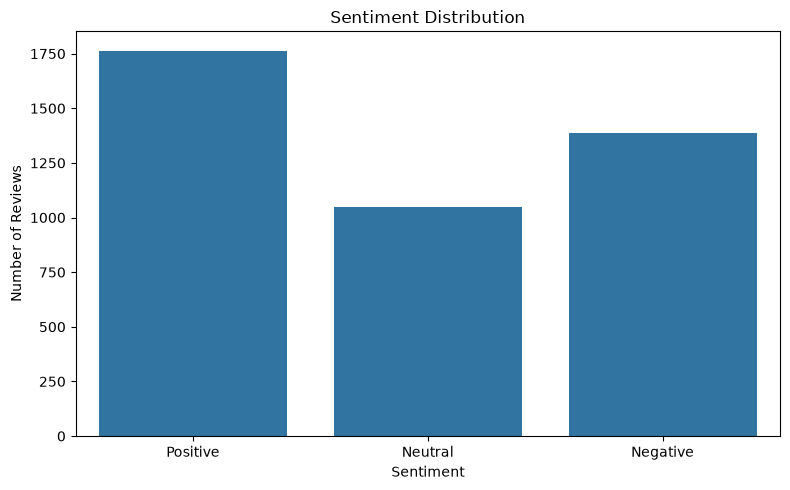

In [10]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="sentiment",
    order=["Positive", "Neutral", "Negative"]
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()

In [11]:
print("Number of unique brands:", df["brand"].nunique())
print("Number of unique models:", df["model"].nunique())

Number of unique brands: 9
Number of unique models: 32


In [12]:
print("\nBrands:")
print(df["brand"].value_counts())


Brands:
brand
Samsung     700
Apple       700
Google      520
OnePlus     390
Motorola    390
Realme      375
OPPO        375
Xiaomi      375
Nothing     375
Name: count, dtype: int64


In [13]:
print("\nSmartphone models:")
print(df["model"].value_counts())


Smartphone models:
model
Galaxy S25 Ultra        140
iPhone 16e              140
Galaxy S26              140
Galaxy A56 5G           140
iPhone 17 Pro           140
iPhone 17 Pro Max       140
Galaxy S26 Ultra        140
iPhone 16               140
Galaxy Z Flip7          140
iPhone 17               140
Moto G Power 2025       140
Pixel 10                130
OnePlus 13              130
OnePlus 13R             130
Pixel 10 Pro XL         130
Pixel 9a                130
Pixel 10 Pro            130
OnePlus 13T             130
Realme GT 7 Pro         125
Find X8 Pro             125
Reno 13 Pro             125
Xiaomi 15               125
Phone 3a Pro            125
Redmi Note 14 Pro+      125
Nothing Phone 3         125
Razr 60 Ultra           125
Phone 2a Plus           125
Realme GT 7             125
Xiaomi 15 Ultra         125
Realme 14 Pro+          125
Motorola Edge 60 Pro    125
Find N5                 125
Name: count, dtype: int64


In [14]:
aspect_cols = [
    "battery_life_rating",
    "camera_rating",
    "performance_rating",
    "design_rating",
    "display_rating"
]

model_aspect_means = (
    df.groupby(["brand", "model"])[aspect_cols]
    .mean()
    .round(2)
)

model_aspect_means

battery_life_rating  camera_rating  \
brand    model                                                      
Apple    iPhone 16                            3.49           3.96   
         iPhone 16e                           2.91           2.71   
         iPhone 17                            3.96           4.25   
         iPhone 17 Pro                        4.29           4.46   
         iPhone 17 Pro Max                    4.51           4.78   
Google   Pixel 10                             3.29           4.15   
         Pixel 10 Pro                         3.49           4.38   
         Pixel 10 Pro XL                      3.65           4.51   
         Pixel 9a                             3.54           3.48   
Motorola Moto G Power 2025                    4.22           2.27   
         Motorola Edge 60 Pro                 4.11           3.62   
         Razr 60 Ultra                        2.66           3.47   
Nothing  Nothing Phone 3                      3.81           3.66   
         Phone 2a Plus                        3.95           2.62   
         Phone 3a Pro                         3.82           3.42   
OPPO     Find N5                              2.22           3.22   
         Find X8 Pro                          4.14           4.32   
         Reno 13 Pro                          3.66           3.83   
OnePlus  OnePlus 13                           4.18           4.00   
         OnePlus 13R                          4.28           3.69   
         OnePlus 13T                          4.01           3.70   
Realme   Realme 14 Pro+                       3.76           3.02   
         Realme GT 7                          4.18           3.35   
         Realme GT 7 Pro                      4.15           3.69   
Samsung  Galaxy A56 5G                        3.34           2.89   
         Galaxy S25 Ultra                     4.36           4.54   
         Galaxy S26                           4.21           4.31   
         Galaxy S26 Ultra                     4.55           4.59   
         Galaxy Z Flip7                       2.61           3.51   
Xiaomi   Redmi Note 14 Pro+                   3.90           2.89   
         Xiaomi 15                            3.74           4.12   
         Xiaomi 15 Ultra                      4.07           4.54   

                               performance_rating  design_rating  \
brand    model                                                     
Apple    iPhone 16                           4.01           3.86   
         iPhone 16e                          3.59           3.33   
         iPhone 17                           4.24           4.29   
         iPhone 17 Pro                       4.55           4.44   
         iPhone 17 Pro Max                   4.74           4.59   
Google   Pixel 10                            3.58           3.56   
         Pixel 10 Pro                        3.96           3.65   
         Pixel 10 Pro XL                     4.13           4.01   
         Pixel 9a                            2.93           3.50   
Motorola Moto G Power 2025                   2.31           2.80   
         Motorola Edge 60 Pro                3.66           4.12   
         Razr 60 Ultra                       3.49           4.02   
Nothing  Nothing Phone 3                     3.86           4.18   
         Phone 2a Plus                       2.96           3.35   
         Phone 3a Pro                        3.42           3.94   
OPPO     Find N5                             3.20           4.07   
         Find X8 Pro                         4.30           3.99   
         Reno 13 Pro                         3.54           4.01   
OnePlus  OnePlus 13                          4.65           4.14   
         OnePlus 13R                         4.29           3.72   
         OnePlus 13T                         4.42           3.95   
Realme   Realme 14 Pro+                      3.28           3.62   
         Realme GT 7                         4.24   

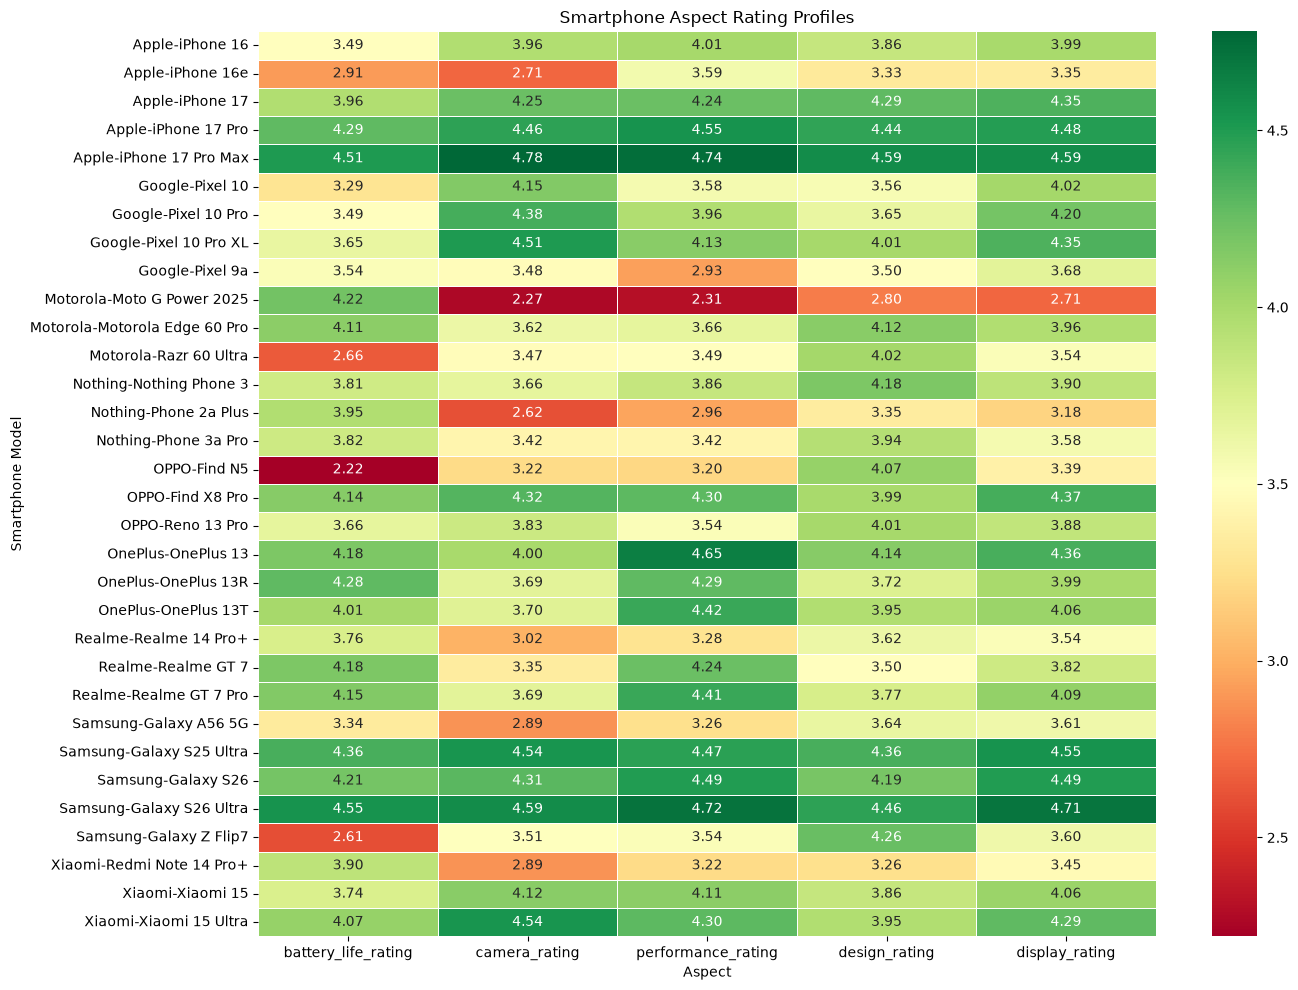

In [15]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    model_aspect_means,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    linewidths=0.5
)

plt.title("Smartphone Aspect Rating Profiles")
plt.xlabel("Aspect")
plt.ylabel("Smartphone Model")

plt.tight_layout()
plt.show()

In [16]:
model_aspect_std = (
    df.groupby("model")[aspect_cols]
    .std()
    .round(2)
)

model_aspect_std

,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating
model,,,,,
Find N5,0.91,0.92,0.86,0.72,0.83
Find X8 Pro,0.72,0.60,0.67,0.75,0.65
Galaxy A56 5G,0.89,0.74,0.86,0.77,0.82
Galaxy S25 Ultra,0.58,0.53,0.54,0.60,0.51
Galaxy S26,0.64,0.56,0.54,0.67,0.56
Galaxy S26 Ultra,0.57,0.52,0.47,0.53,0.45
Galaxy Z Flip7,0.90,0.80,0.80,0.63,0.82
Moto G Power 2025,0.61,0.97,0.91,0.83,0.93
Motorola Edge 60 Pro,0.69,0.80,0.88,0.74,0.80


In [17]:
overall_aspect_stats = df[aspect_cols].agg(
    ["mean", "std", "min", "max"]
).T.round(3)

overall_aspect_stats

,mean,std,min,max
battery_life_rating,3.786,0.931,1.0,5.0
camera_rating,3.754,0.996,1.0,5.0
performance_rating,3.877,0.945,1.0,5.0
design_rating,3.891,0.834,1.0,5.0
display_rating,3.948,0.856,1.0,5.0
